<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


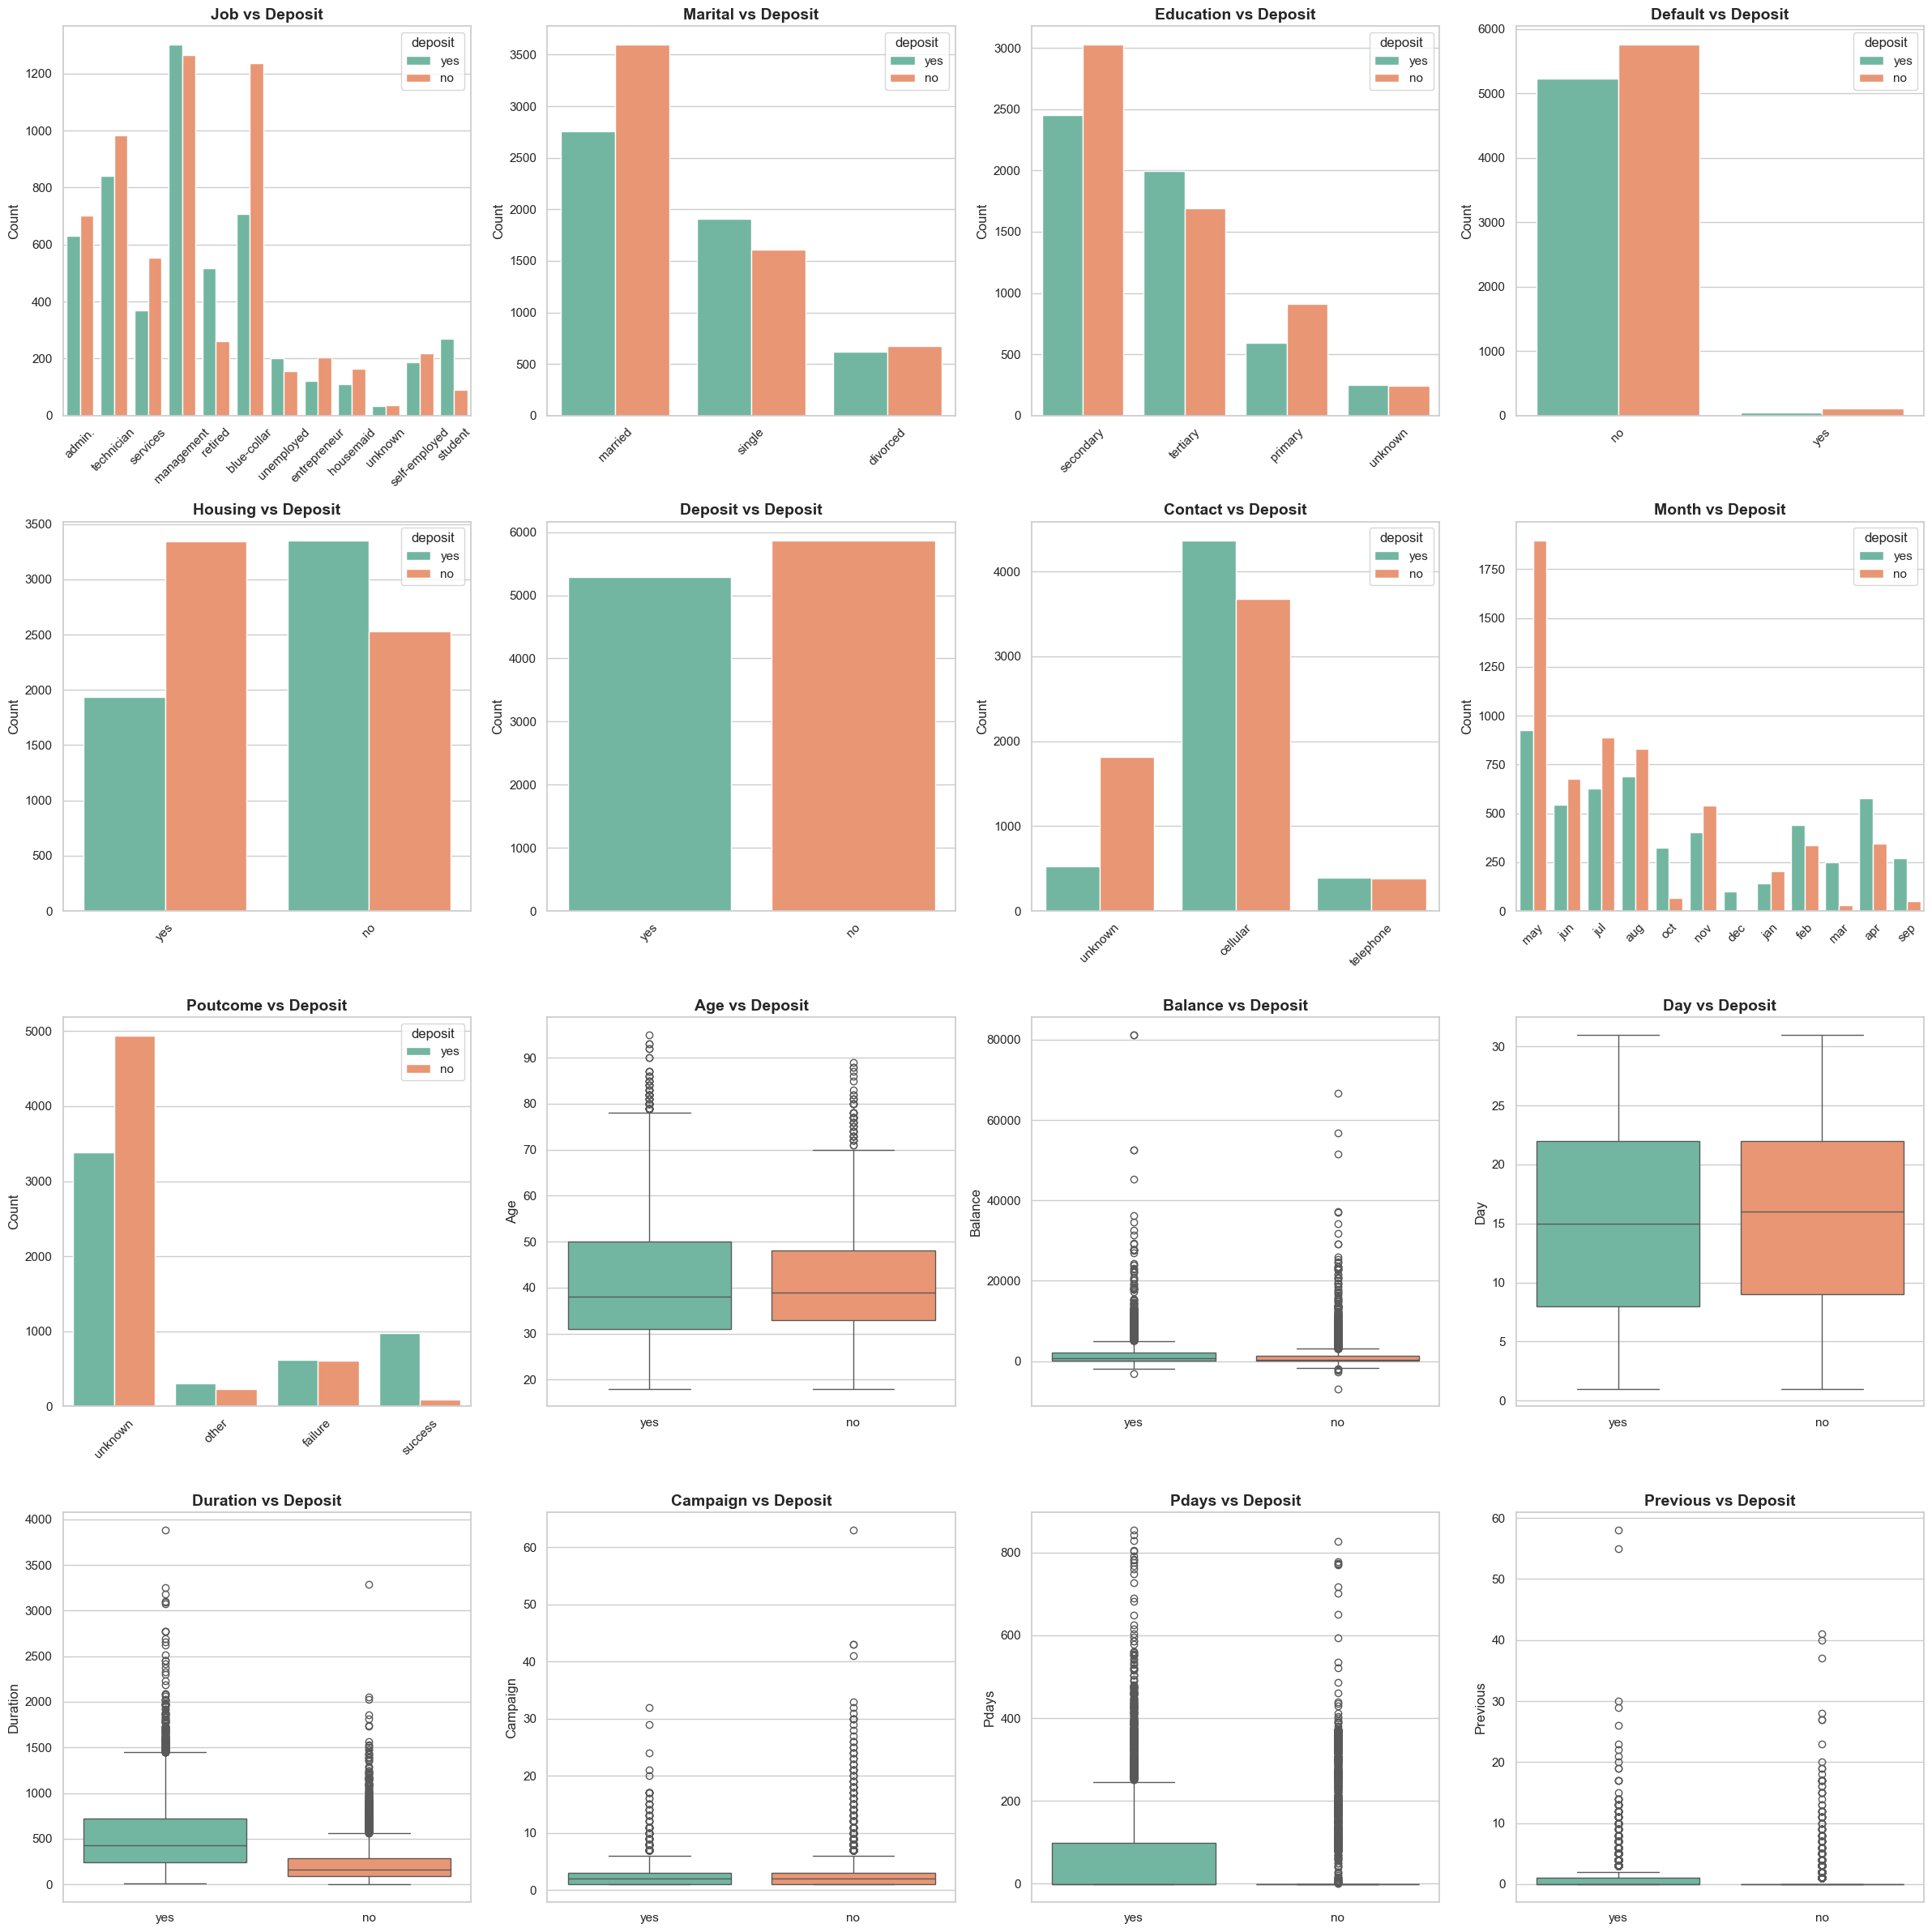

Original dataset size: 11162 rows
Cleaned dataset size: 9904 rows
              precision    recall  f1-score   support

           0       0.86      1.00      0.93      1705
           1       0.71      0.02      0.04       276

    accuracy                           0.86      1981
   macro avg       0.79      0.51      0.48      1981
weighted avg       0.84      0.86      0.80      1981

              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1705
           1       0.24      0.27      0.26       276

    accuracy                           0.78      1981
   macro avg       0.56      0.57      0.56      1981
weighted avg       0.79      0.78      0.79      1981

--- Top 10 Characteristics Most Likely to Accept ---
            Feature  Impact on Probability
          month_jul               1.013732
   job_entrepreneur               0.576915
    job_blue-collar               0.412945
         job_admin.               0.408759
          mo

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

dataset=pd.read_csv('Datasets/bank.csv')

dataset.head()

dataset.shape

dataset.describe()

dataset.info()

dataset.drop_duplicates(inplace=True)

dataset.isnull().sum()

### Data Visualizations

# 2. Define your columns
# We separate them because categorical and numerical data require different plot types
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'deposit', 'contact', 'month', 'poutcome']
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Combine them for the loop. 9 categorical + 7 numerical = 16 features.
features = cat_cols + num_cols 

# 3. Set up the 4x4 figure grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 4, figsize=(24, 24))
axes = axes.flatten() # Flattens the 2D grid array to 1D for easy looping

# 4. Loop through features and generate the corresponding plot
for i, col in enumerate(features):
    if col in cat_cols:
        # For text/category columns: draw a bar chart counting the occurrences
        sns.countplot(data=dataset, x=col, hue='deposit', ax=axes[i], palette='Set2')
        axes[i].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap
        axes[i].set_ylabel('Count')
    else:
        # For numerical columns: draw a boxplot to show distribution and outliers
        sns.boxplot(data=dataset, x='deposit', y=col, ax=axes[i], palette='Set2')
        axes[i].set_ylabel(col.capitalize())
        
    # Standardize the titles and clean up x-axis labels
    axes[i].set_title(f'{col.capitalize()} vs Deposit', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# 5. Adjust layout so nothing overlaps and show the plot
plt.tight_layout()
plt.show()

### As get to know that dataset has outliers So I remove them 

# 3. Create a function to remove outliers using IQR
def remove_outliers_iqr(dataset, columns):
    df_clean = dataset.copy()
    
    for col in columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = dataset[col].quantile(0.25)
        Q3 = dataset[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Define the lower and upper bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Filter the dataframe to keep only the rows within the bounds
        df_clean = dataset[(dataset[col] >= lower_bound) & (dataset[col] <= upper_bound)]
        
    return df_clean

# 4. Apply the function
print(f"Original dataset size: {len(dataset)} rows")
dataset_clean = remove_outliers_iqr(dataset, num_cols)
print(f"Cleaned dataset size: {len(dataset_clean)} rows")


### Pipeline to prevent Data leakage

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

# Build the Pipelines
# Pipeline 1: Logistic Regression
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
# Pipeline 2 :Decision Tree Classifier
pipeline_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

X = dataset_clean.drop('loan', axis=1)
y = dataset_clean['loan'].map({'yes': 1, 'no': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Models Creation

pipeline_lr.fit(X_train,y_train)

lr_pred=pipeline_lr.predict(X_test)

print(classification_report(y_test,lr_pred))

pipeline_dt.fit(X_train,y_train)

dt_pred=pipeline_dt.predict(X_test)

print(classification_report(y_test,dt_pred))

# Extract the trained model and preprocessor from the pipeline
classifier = pipeline_lr.named_steps['classifier']
preprocessor = pipeline_lr.named_steps['preprocessor']

# Get the feature names
num_features = num_cols # From your original list
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(num_features) + list(cat_features)

# Get the coefficients (weights) assigned by the model
coefficients = classifier.coef_[0]

# Combine into a DataFrame for easy viewing
coef_df = pd.DataFrame({
    'Feature': all_features, 
    'Impact on Probability': coefficients
})

# Sort to find the strongest predictors for "Yes"
top_drivers = coef_df.sort_values(by='Impact on Probability', ascending=False)

print("--- Top 10 Characteristics Most Likely to Accept ---")
print(top_drivers.head(10).to_string(index=False))

print("\n--- Top 10 Characteristics Least Likely to Accept ---")
print(top_drivers.tail(10).to_string(index=False))



